In [3]:
import requests
import pandas as pd

url = "https://api.coingecko.com/api/v3/coins/markets"

params = {
    "vs_currency": "usd",
    "order": "market_cap_desc",
    "per_page": 50,   # pull more so filtering still leaves ~20
    "page": 1,
    "sparkline": False
}

response = requests.get(url, params=params)
data = response.json()

df = pd.DataFrame(data)[
    ["market_cap_rank", "symbol", "name", "market_cap", "current_price"]
]

# -----------------------------
# Filters
# -----------------------------

stablecoins = {
    "usdt", "usdc", "busd", "dai", "tusd",
    "usdp", "fdusd", "gusd", "lusd",
    "ust", "ustc", "usdd", "eurc",'usds','usde','bsc-usd','usd1','pyusd'
    
}

# normalize text
df["symbol"] = df["symbol"].str.lower()
df["name"] = df["name"].str.lower()

# remove stablecoins
df = df[~df["symbol"].isin(stablecoins)]

# remove wrapped coins
df = df[
    ~df["name"].str.contains("wrapped") &
    ~df["symbol"].str.startswith("w")
]

# take top 20 after filtering
df = df.sort_values("market_cap", ascending=False).head(20)

print(df)


    market_cap_rank      symbol          name     market_cap  current_price
0                 1         btc       bitcoin  1394014934104   69696.000000
1                 2         eth      ethereum   243009169166    2013.420000
3                 4         bnb           bnb    87381158073     640.770000
4                 5         xrp           xrp    84420845022       1.380000
6                 7         sol        solana    48801440562      85.480000
7                 8         trx          tron    27199893894       0.287096
8                 9  figr_heloc  figure heloc    16292022193       1.036000
9                10        doge      dogecoin    14096408185       0.091921
12               13         ada       cardano     9487776558       0.257579
13               14         bch  bitcoin cash     8989444943     449.530000
14               15         leo     leo token     8451076649       9.170000
15               16        hype   hyperliquid     8212485414      34.440000
16          

In [4]:
binance_symbols = requests.get(
    "https://api.binance.com/api/v3/exchangeInfo"
).json()

binance_assets = {
    s["baseAsset"].lower()
    for s in binance_symbols["symbols"]
    if s["quoteAsset"] == "USDT"
}

df = df[df["symbol"].isin(binance_assets)]

In [5]:
df

,market_cap_rank,symbol,name,market_cap,current_price
0,1,btc,bitcoin,1394014934104,69696.000000
1,2,eth,ethereum,243009169166,2013.420000
3,4,bnb,bnb,87381158073,640.770000
4,5,xrp,xrp,84420845022,1.380000
6,7,sol,solana,48801440562,85.480000
7,8,trx,tron,27199893894,0.287096
9,10,doge,dogecoin,14096408185,0.091921
12,13,ada,cardano,9487776558,0.257579
13,14,bch,bitcoin cash,8989444943,449.530000
16,17,xmr,monero,6519903577,353.480000


In [6]:
from binance.client import Client
import datetime
client = Client()


end_date = datetime.datetime.now()
start_date = end_date - datetime.timedelta(days=60)

klines_btc = client.get_historical_klines(
    "BTCUSDT",                     # symbol
    Client.KLINE_INTERVAL_15MINUTE,    # interval:15 minutes
    start_date.strftime("%d %b %Y %H:%M:%S"),
    end_date.strftime("%d %b %Y %H:%M:%S")
)
df_btc = pd.DataFrame(klines_btc, columns=[
    "timestamp", "open", "high", "low", "close", "volume",
    "close_time", "quote_asset_volume", "number_of_trades",
    "taker_buy_base", "taker_buy_quote", "ignore"
])
df_btc=df_btc[['timestamp','close']]

klines_eth = client.get_historical_klines(
    "ETHUSDT",                     # symbol
    Client.KLINE_INTERVAL_15MINUTE,    # interval:15 minutes
    start_date.strftime("%d %b %Y %H:%M:%S"),
    end_date.strftime("%d %b %Y %H:%M:%S")
)
klines_bnb = client.get_historical_klines(
    "BNBUSDT",                     # symbol
    Client.KLINE_INTERVAL_15MINUTE,    # interval:15 minutes
    start_date.strftime("%d %b %Y %H:%M:%S"),
    end_date.strftime("%d %b %Y %H:%M:%S")
)


C:\Users\Acer\AppData\Local\Temp\ipykernel_2972\3929911776.py:9: DeprecationWarning: Parsing dates involving a day of month without a year specified is ambiguious
and fails to parse leap day. The default behavior will change in Python 3.15
to either always raise an exception or to use a different default year (TBD).
To avoid trouble, add a specific year to the input & format.
See https://github.com/python/cpython/issues/70647.
  klines_btc = client.get_historical_klines(
C:\Users\Acer\AppData\Local\Temp\ipykernel_2972\3929911776.py:22: DeprecationWarning: Parsing dates involving a day of month without a year specified is ambiguious
and fails to parse leap day. The default behavior will change in Python 3.15
to either always raise an exception or to use a different default year (TBD).
To avoid trouble, add a specific year to the input & format.
See https://github.com/python/cpython/issues/70647.
  klines_eth = client.get_historical_klines(
C:\Users\Acer\AppData\Local\Temp\ipykernel_2972

In [7]:
import pandas as pd
from binance.client import Client

def get_close_prices_15m(
    client,
    symbols,
    start_date,
    end_date
):
    """
    Download 15-minute close prices for selected coins.

    Parameters
    ----------
    client : Binance Client
    symbols : list[str]
        Example: ["BTC", "ETH", "BNB", "SOL"]
    start_date : datetime
    end_date : datetime

    Returns
    -------
    pd.DataFrame
        timestamp × coin close prices
    """

    close_dfs = []

    for sym in symbols:
        pair = sym.upper() + "USDT"
        print(f"Downloading {pair}")

        klines = client.get_historical_klines(
            pair,
            Client.KLINE_INTERVAL_15MINUTE,
            start_date.strftime("%d %b %Y %H:%M:%S"),
            end_date.strftime("%d %b %Y %H:%M:%S")
        )

        df = pd.DataFrame(klines, columns=[
            "timestamp", "open", "high", "low", "close", "volume",
            "close_time", "quote_asset_volume", "number_of_trades",
            "taker_buy_base", "taker_buy_quote", "ignore"
        ])

        df = df[["timestamp", "close"]]
        df["timestamp"] = pd.to_datetime(df["timestamp"], unit="ms")
        df["close"] = df["close"].astype(float)

        df = df.rename(columns={"close": sym.upper()})

        close_dfs.append(df)

    # ---- merge all coins on timestamp ----
    df_close = close_dfs[0]

    for d in close_dfs[1:]:
        df_close = df_close.merge(
            d,
            on="timestamp",
            how="outer"
        )

    df_close = (
        df_close
        .sort_values("timestamp")
        .set_index("timestamp")
    )

    return df_close


In [8]:

import datetime



#start_date = datetime(2025, 1, 1)
end_date = datetime.datetime.now()
start_date = end_date - datetime.timedelta(days=30)


df_close_15m = get_close_prices_15m(
    client,
    df['symbol'].tolist(),
    start_date,
    end_date
)


C:\Users\Acer\AppData\Local\Temp\ipykernel_2972\3597688465.py:33: DeprecationWarning: Parsing dates involving a day of month without a year specified is ambiguious
and fails to parse leap day. The default behavior will change in Python 3.15
to either always raise an exception or to use a different default year (TBD).
To avoid trouble, add a specific year to the input & format.
See https://github.com/python/cpython/issues/70647.
  klines = client.get_historical_klines(


C:\Users\Acer\AppData\Local\Temp\ipykernel_2972\3597688465.py:33: DeprecationWarning: Parsing dates involving a day of month without a year specified is ambiguious
and fails to parse leap day. The default behavior will change in Python 3.15
to either always raise an exception or to use a different default year (TBD).
To avoid trouble, add a specific year to the input & format.
See https://github.com/python/cpython/issues/70647.
  klines = client.get_historical_klines(


C:\Users\Acer\AppData\Local\Temp\ipykernel_2972\3597688465.py:33: DeprecationWarning: Parsing dates involving a day of month without a year specified is ambiguious
and fails to parse leap day. The default behavior will change in Python 3.15
to either always raise an exception or to use a different default year (TBD).
To avoid trouble, add a specific year to the input & format.
See https://github.com/python/cpython/issues/70647.
  klines = client.get_historical_klines(


C:\Users\Acer\AppData\Local\Temp\ipykernel_2972\3597688465.py:33: DeprecationWarning: Parsing dates involving a day of month without a year specified is ambiguious
and fails to parse leap day. The default behavior will change in Python 3.15
to either always raise an exception or to use a different default year (TBD).
To avoid trouble, add a specific year to the input & format.
See https://github.com/python/cpython/issues/70647.
  klines = client.get_historical_klines(


C:\Users\Acer\AppData\Local\Temp\ipykernel_2972\3597688465.py:33: DeprecationWarning: Parsing dates involving a day of month without a year specified is ambiguious
and fails to parse leap day. The default behavior will change in Python 3.15
to either always raise an exception or to use a different default year (TBD).
To avoid trouble, add a specific year to the input & format.
See https://github.com/python/cpython/issues/70647.
  klines = client.get_historical_klines(


...

C:\Users\Acer\AppData\Local\Temp\ipykernel_2972\3597688465.py:33: DeprecationWarning: Parsing dates involving a day of month without a year specified is ambiguious
and fails to parse leap day. The default behavior will change in Python 3.15
to either always raise an exception or to use a different default year (TBD).
To avoid trouble, add a specific year to the input & format.
See https://github.com/python/cpython/issues/70647.
  klines = client.get_historical_klines(
C:\Users\Acer\AppData\Local\Temp\ipykernel_2972\3597688465.py:33: DeprecationWarning: Parsing dates involving a day of month without a year specified is ambiguious
and fails to parse leap day. The default behavior will change in Python 3.15
to either always raise an exception or to use a different default year (TBD).
To avoid trouble, add a specific year to the input & format.
See https://github.com/python/cpython/issues/70647.
  klines = client.get_historical_klines(


C:\Users\Acer\AppData\Local\Temp\ipykernel_2972\3597688465.py:33: DeprecationWarning: Parsing dates involving a day of month without a year specified is ambiguious
and fails to parse leap day. The default behavior will change in Python 3.15
to either always raise an exception or to use a different default year (TBD).
To avoid trouble, add a specific year to the input & format.
See https://github.com/python/cpython/issues/70647.
  klines = client.get_historical_klines(


C:\Users\Acer\AppData\Local\Temp\ipykernel_2972\3597688465.py:33: DeprecationWarning: Parsing dates involving a day of month without a year specified is ambiguious
and fails to parse leap day. The default behavior will change in Python 3.15
to either always raise an exception or to use a different default year (TBD).
To avoid trouble, add a specific year to the input & format.
See https://github.com/python/cpython/issues/70647.
  klines = client.get_historical_klines(


C:\Users\Acer\AppData\Local\Temp\ipykernel_2972\3597688465.py:33: DeprecationWarning: Parsing dates involving a day of month without a year specified is ambiguious
and fails to parse leap day. The default behavior will change in Python 3.15
to either always raise an exception or to use a different default year (TBD).
To avoid trouble, add a specific year to the input & format.
See https://github.com/python/cpython/issues/70647.
  klines = client.get_historical_klines(


C:\Users\Acer\AppData\Local\Temp\ipykernel_2972\3597688465.py:33: DeprecationWarning: Parsing dates involving a day of month without a year specified is ambiguious
and fails to parse leap day. The default behavior will change in Python 3.15
to either always raise an exception or to use a different default year (TBD).
To avoid trouble, add a specific year to the input & format.
See https://github.com/python/cpython/issues/70647.
  klines = client.get_historical_klines(


Text(0, 0.5, 'Price')

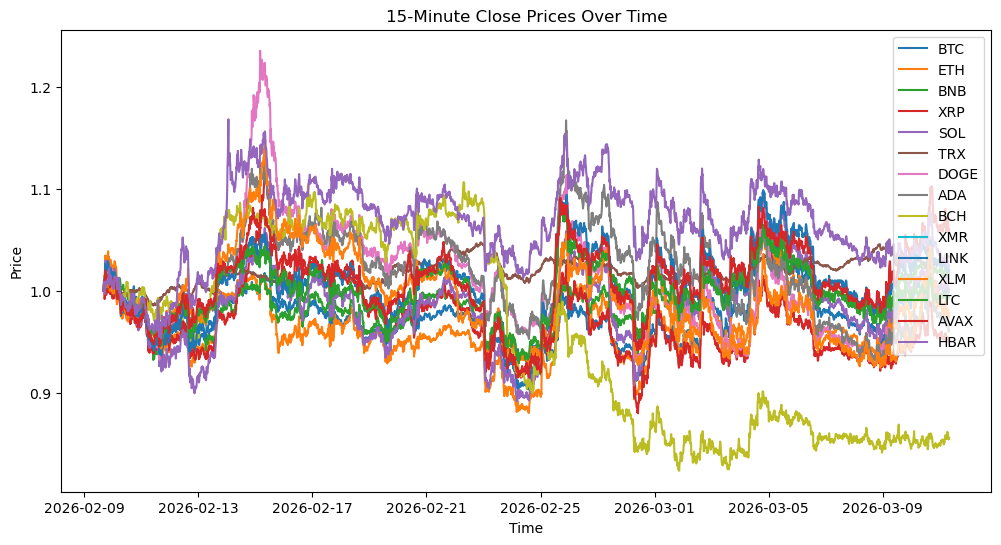

In [9]:
import matplotlib.pyplot as plt

normalized_df = df_close_15m / df_close_15m.iloc[0]  # Normalize to the first row

plt.figure(figsize=(12, 6))
for col in normalized_df.columns:
    plt.plot(normalized_df.index, normalized_df[col], label=col)
plt.legend()
plt.title("15-Minute Close Prices Over Time")
plt.xlabel("Time")
plt.ylabel("Price")

In [10]:
normalized_df.head()

,BTC,ETH,BNB,XRP,SOL,TRX,DOGE,ADA,BCH,XMR,LINK,XLM,LTC,AVAX,HBAR
timestamp,,,,,,,,,,,,,,,
2026-02-09 16:15:00,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,NaN,1.000000,1.000000,1.000000,1.000000,1.000000
2026-02-09 16:30:00,1.004856,1.009885,1.005479,1.003384,1.006668,1.001080,1.005796,1.006721,1.006282,NaN,1.008028,1.003752,1.005726,1.008909,1.001853
2026-02-09 16:45:00,1.007026,1.014806,1.009290,1.002625,1.007370,1.002159,1.006850,1.007468,1.003046,NaN,1.011468,1.002502,1.005541,1.010022,1.009047
2026-02-09 17:00:00,1.004632,1.011113,1.004303,0.992057,1.003393,1.001439,0.999262,1.001867,1.005330,NaN,1.005734,0.997498,1.000739,1.004454,1.003597
2026-02-09 17:15:00,1.006398,1.012156,1.006828,0.993300,1.012518,1.002519,1.003478,1.004854,1.007615,NaN,1.008028,1.000625,1.003879,1.004454,0.997384


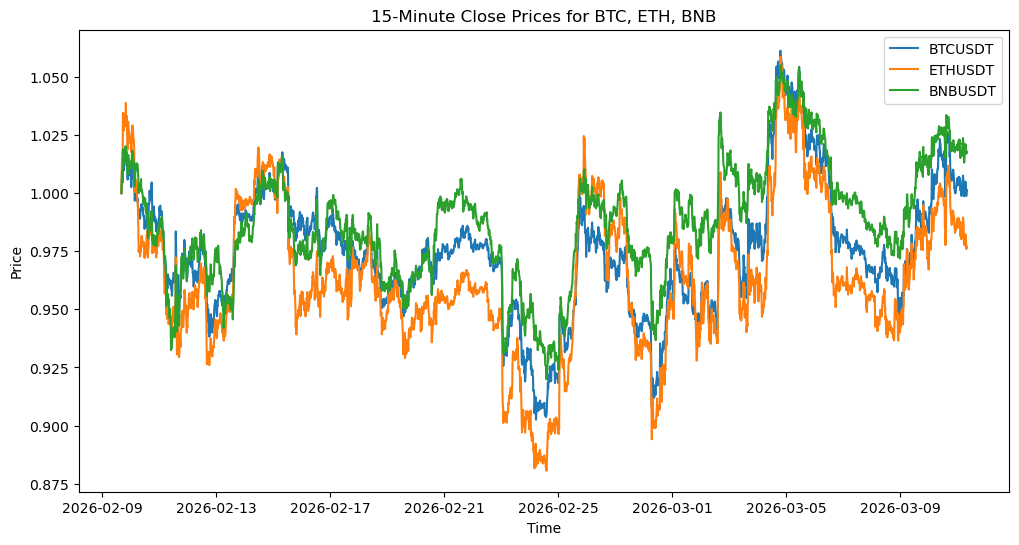

In [11]:
plt.figure(figsize=(12,6))
plt.plot(normalized_df.index, normalized_df['BTC'], label='BTCUSDT')
plt.plot(normalized_df.index, normalized_df['ETH'], label='ETHUSDT')
plt.plot(normalized_df.index, normalized_df['BNB'], label='BNBUSDT')
plt.legend()
plt.title("15-Minute Close Prices for BTC, ETH, BNB")
plt.xlabel("Time")
plt.ylabel("Price")
plt.show()

In [12]:
normalized_df.head()
# Drop columns where ALL values are NaN
df_close_15m = df_close_15m.dropna(axis=1, how='all')
normalized_df=normalized_df.dropna(axis=1, how='all')

# Or drop columns with ANY NaN values
#df_close_15m = df_close_15m.dropna(axis=1, how='any')

In [13]:
df_close_15m

,BTC,ETH,BNB,XRP,SOL,TRX,DOGE,ADA,BCH,LINK,XLM,LTC,AVAX,HBAR
timestamp,,,,,,,,,,,,,,
2026-02-09 16:15:00,69604.00,2060.70,629.73,1.4478,85.48,0.2779,0.09489,0.2678,525.3,8.72,0.1599,54.14,8.98,0.09174
2026-02-09 16:30:00,69942.02,2081.07,633.18,1.4527,86.05,0.2782,0.09544,0.2696,528.6,8.79,0.1605,54.45,9.06,0.09191
2026-02-09 16:45:00,70093.01,2091.21,635.58,1.4516,86.11,0.2785,0.09554,0.2698,526.9,8.82,0.1603,54.44,9.07,0.09257
2026-02-09 17:00:00,69926.39,2083.60,632.44,1.4363,85.77,0.2783,0.09482,0.2683,528.1,8.77,0.1595,54.18,9.02,0.09207
2026-02-09 17:15:00,70049.31,2085.75,634.03,1.4381,86.55,0.2786,0.09522,0.2691,529.3,8.79,0.1600,54.35,9.02,0.09150
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-11 07:00:00,69891.19,2023.39,642.78,1.3813,86.03,0.2873,0.09228,0.2593,452.2,8.95,0.1567,53.95,9.60,0.09443
2026-03-11 07:15:00,69791.28,2019.46,642.19,1.3804,85.86,0.2872,0.09219,0.2590,450.3,8.94,0.1562,53.91,9.56,0.09441
2026-03-11 07:30:00,69519.99,2011.13,640.44,1.3754,85.33,0.2871,0.09175,0.2571,448.9,8.89,0.1557,53.75,9.50,0.09394


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def calc_kalman_beta(price_x, price_y):
    """
    Calculates the rolling beta (hedge ratio) using a Kalman Filter.
    
    Parameters:
    price_x (pd.Series): Independent variable (e.g., BTC prices)
    price_y (pd.Series): Dependent variable (e.g., ETH prices)
    
    Returns:
    pd.DataFrame: Contains the rolling alpha, rolling beta, and the estimated y_pred
    """
    # 1. Initialize matrices and state variables
    # State vector: X = [alpha, beta]
    state_mean = np.zeros(2)
    state_cov = np.ones((2, 2))
    
    # Process noise covariance (Q) and Measurement noise covariance (R)
    # The delta value controls how quickly the beta adapts. 
    # Smaller delta = slower adaptation (smoother beta)
    delta = 1e-4 
    Q = (delta / (1 - delta)) * np.eye(2) 
    R = 1.0 
    
    rolling_alpha = []
    rolling_beta = []
    
    # 2. Iterate through prices to apply the Kalman Filter 
    for i in range(len(price_x)):
        x_t = price_x.iloc[i]
        y_t = price_y.iloc[i]
        
        # Observation matrix H_t = [1, x_t]
        H = np.array([[1.0, x_t]])
        
        # --- PREDICTION STEP ---
        # State transitions are identity: X(k|k-1) = X(k-1|k-1)
        state_mean_pred = state_mean
        state_cov_pred = state_cov + Q
        
        # --- UPDATE STEP ---
        # Calculate prediction error (Innovation)
        y_pred = H.dot(state_mean_pred)
        error = y_t - y_pred
        
        # Innovation covariance (S)
        S = H.dot(state_cov_pred).dot(H.T) + R
        
        # Kalman Gain (K)
        K = state_cov_pred.dot(H.T) / S
        
        # Update state mean and covariance
        state_mean = state_mean_pred + (K.flatten() * error)
        state_cov = (np.eye(2) - K.dot(H)).dot(state_cov_pred)
        
        # Store results
        rolling_alpha.append(state_mean[0])
        rolling_beta.append(state_mean[1])
        
    return pd.DataFrame({
        'alpha': rolling_alpha,
        'beta': rolling_beta
    }, index=price_x.index)

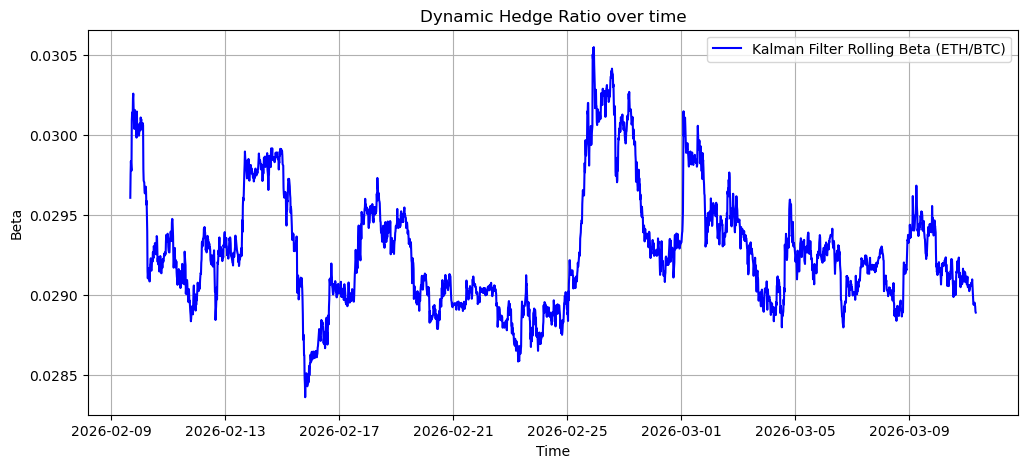

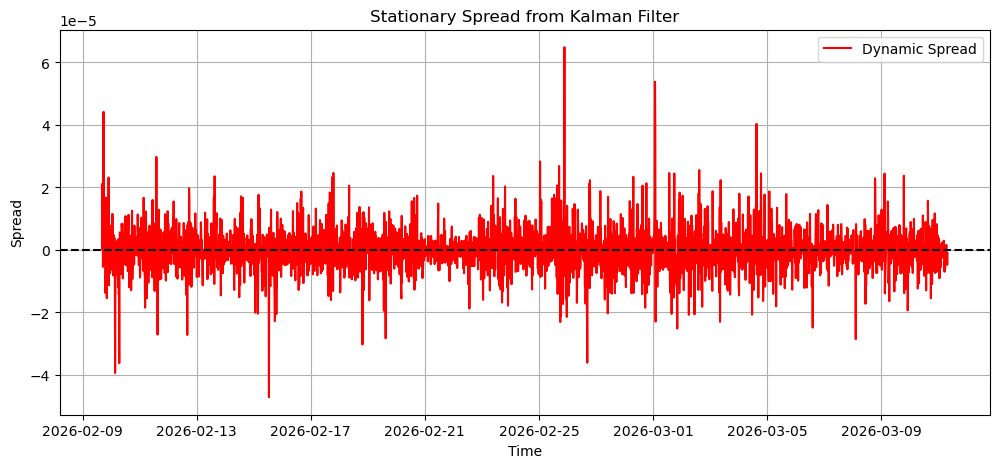

In [15]:
# Assuming df_close_15m is successfully populated from your previous cells
# Drop NA values to ensure alignment
df_pairs = df_close_15m[['BTC', 'ETH']].dropna()

# Apply the Kalman Filter
kalman_states = calc_kalman_beta(df_pairs['BTC'], df_pairs['ETH'])

# Add the rolling beta back to your dataframe
df_pairs['Rolling_Beta'] = kalman_states['beta']
df_pairs['Rolling_Alpha'] = kalman_states['alpha']

# Calculate the dynamic spread (residual)
# Spread = ETH - (Rolling_Beta * BTC + Rolling_Alpha)
df_pairs['Spread'] = df_pairs['ETH'] - (df_pairs['Rolling_Beta'] * df_pairs['BTC'] + df_pairs['Rolling_Alpha'])

# Plotting the Rolling Beta
plt.figure(figsize=(12, 5))
plt.plot(df_pairs.index, df_pairs['Rolling_Beta'], label='Kalman Filter Rolling Beta (ETH/BTC)', color='blue')
plt.title('Dynamic Hedge Ratio over time')
plt.xlabel('Time')
plt.ylabel('Beta')
plt.legend()
plt.grid(True)
plt.show()

# Plotting the Spread
plt.figure(figsize=(12, 5))
plt.plot(df_pairs.index, df_pairs['Spread'], label='Dynamic Spread', color='red')
plt.axhline(0, color='black', linestyle='--')
plt.title('Stationary Spread from Kalman Filter')
plt.xlabel('Time')
plt.ylabel('Spread')
plt.legend()
plt.grid(True)
plt.show()

In [16]:
import numpy as np
from itertools import combinations
from statsmodels.tsa.stattools import coint
import statsmodels.api as sm


In [17]:
def test_cointegration(series_x, series_y):
    """
    Engle-Granger 2-step cointegration test
    """

    # 1️⃣ Hedge ratio (OLS)
    X = sm.add_constant(series_x)
    model = sm.OLS(series_y, X).fit()
    beta = model.params[1]

    spread = series_y - beta * series_x

    # 2️⃣ Cointegration test
    score, pvalue, crit = coint(series_y, series_x)

    return {
        "beta": beta,
        "pvalue": pvalue,
        "t_stat": score,
        "crit_1%": crit[0],
        "crit_5%": crit[1],
        "crit_10%": crit[2],
        "spread": spread
    }


In [18]:
results = []

pairs = list(combinations(normalized_df.columns, 2))

for x, y in pairs:
    res = test_cointegration(normalized_df[x], normalized_df[y])

    results.append({
        "pair": f"{x}-{y}",
        "x": x,
        "y": y,
        "beta": res["beta"],
        "pvalue": res["pvalue"],
        "t_stat": res["t_stat"],
        "crit_5%": res["crit_5%"]
    })

df_coint = pd.DataFrame(results)


C:\Users\Acer\AppData\Local\Temp\ipykernel_2972\905122118.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  beta = model.params[1]
C:\Users\Acer\AppData\Local\Temp\ipykernel_2972\905122118.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  beta = model.params[1]
C:\Users\Acer\AppData\Local\Temp\ipykernel_2972\905122118.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  beta = model.params[1]
C:\Users\Acer\AppData\Local\Temp\ipyk

In [19]:
df_coint[:20].sort_values("pvalue")

,pair,x,y,beta,pvalue,t_stat,crit_5%
0,BTC-ETH,BTC,ETH,1.068353,0.064451,-3.233825,-3.338277
1,BTC-BNB,BTC,BNB,0.814659,0.066472,-3.221087,-3.338277
15,ETH-SOL,ETH,SOL,1.067152,0.125853,-2.937372,-3.338277
10,BTC-LTC,BTC,LTC,0.690680,0.133888,-2.907403,-3.338277
11,BTC-AVAX,BTC,AVAX,1.017365,0.171629,-2.781541,-3.338277
13,ETH-BNB,ETH,BNB,0.688542,0.176814,-2.765786,-3.338277
5,BTC-DOGE,BTC,DOGE,0.678369,0.196823,-2.707696,-3.338277
8,BTC-LINK,BTC,LINK,0.958982,0.207147,-2.679204,-3.338277
17,ETH-DOGE,ETH,DOGE,0.648034,0.218337,-2.649310,-3.338277
3,BTC-SOL,BTC,SOL,1.203556,0.224206,-2.634006,-3.338277


In [20]:
coint_pairs = df_coint[df_coint["pvalue"] < 0.05]
coint_pairs = coint_pairs.sort_values("pvalue")
coint_pairs

,pair,x,y,beta,pvalue,t_stat,crit_5%
52,SOL-LTC,SOL,LTC,0.607851,0.000568,-4.698298,-3.338277
38,XRP-DOGE,XRP,DOGE,1.394763,0.002617,-4.293883,-3.338277
50,SOL-LINK,SOL,LINK,0.833476,0.008648,-3.942848,-3.338277
82,LINK-LTC,LINK,LTC,0.718354,0.016355,-3.738159,-3.338277
66,DOGE-XLM,DOGE,XLM,0.727983,0.017118,-3.722921,-3.338277
42,XRP-XLM,XRP,XLM,1.099010,0.022837,-3.624575,-3.338277
76,BCH-LINK,BCH,LINK,-0.035292,0.033227,-3.490722,-3.338277
22,ETH-LTC,ETH,LTC,0.665934,0.036224,-3.458822,-3.338277
60,TRX-LTC,TRX,LTC,0.626626,0.041093,-3.411463,-3.338277
78,BCH-LTC,BCH,LTC,0.020999,0.044800,-3.378460,-3.338277


In [21]:
btc_pairs = coint_pairs[
    (coint_pairs["x"] == "BTC") |
    (coint_pairs["y"] == "BTC")
]

btc_pairs



,pair,x,y,beta,pvalue,t_stat,crit_5%


In [22]:
btc_pairs['pair'].tolist()

pairs = btc_pairs["pair"].tolist()

btc_hedges = [p.replace("BTC-", "") for p in pairs]


btc_hedges

[]

In [23]:


Y = np.log(df_close_15m["BTC"])
X = np.log(df_close_15m[btc_hedges])

data = pd.concat([Y, X], axis=1).dropna()

Y = data["BTC"]
X = data[btc_hedges]




In [24]:
df_close_15m[['BTC','ETH','SOL']].head()


,BTC,ETH,SOL
timestamp,,,
2026-02-09 16:15:00,69604.00,2060.70,85.48
2026-02-09 16:30:00,69942.02,2081.07,86.05
2026-02-09 16:45:00,70093.01,2091.21,86.11
2026-02-09 17:00:00,69926.39,2083.60,85.77
2026-02-09 17:15:00,70049.31,2085.75,86.55


In [25]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

def build_spread(prices: pd.DataFrame, x: str, y: str, beta: float, use_log=True):
    px = prices[x].astype(float)
    py = prices[y].astype(float)
    if use_log:
        px = np.log(px)
        py = np.log(py)
    spread = py - beta * px
    return spread.dropna()


In [26]:
def fit_ou_from_spread(spread: pd.Series, delta=1.0):
    s = spread.values
    s_t = s[:-1]
    s_t1 = s[1:]

    X = sm.add_constant(s_t)
    res = sm.OLS(s_t1, X).fit()

    b = float(res.params[0])
    a = float(res.params[1])

    # guardrails
    if not (0 < a < 1):
        return None  # not mean-reverting in discrete-time sense

    eps = res.resid
    sd_eps = float(np.std(eps, ddof=1))

    lam = -np.log(a) / delta
    mu = b / (1 - a)
    sigma = sd_eps * np.sqrt((-2*np.log(a)) / (delta*(1 - a*a)))

    half_life = np.log(2) / lam

    return {
        "a": a, "b": b,
        "lambda": lam,
        "mu": mu,
        "sigma": sigma,
        "half_life": half_life,
        "r2": float(res.rsquared)
    }


In [27]:
def ou_zscore(spread: pd.Series, mu: float, sigma: float):
    return (spread - mu) / sigma

def percentile_signals(z: pd.Series, lookback=90, p_low=25, p_high=75, p_exit=50):
    sig = pd.Series(0, index=z.index, dtype=int)

    for i in range(lookback, len(z)):
        hist = z.iloc[i-lookback:i]
        lo = np.percentile(hist, p_low)
        hi = np.percentile(hist, p_high)
        mid = np.percentile(hist, p_exit)

        if z.iloc[i] > hi:
            sig.iloc[i] = -1   # short spread
        elif z.iloc[i] < lo:
            sig.iloc[i] = 1    # long spread
        elif (z.iloc[i-1] - mid) * (z.iloc[i] - mid) <= 0:
            sig.iloc[i] = 0    # exit when cross mid
        else:
            sig.iloc[i] = sig.iloc[i-1]  # hold previous position

    return sig


In [28]:
def run_ou_for_pairs(pairs_df: pd.DataFrame, prices: pd.DataFrame,
                     train_frac=0.7, delta=1.0):
    results = []

    for _, row in pairs_df.iterrows():
        x, y, beta = row["x"], row["y"], float(row["beta"])

        spread = build_spread(prices, x=x, y=y, beta=beta, use_log=True)
        if len(spread) < 200:
            continue

        split = int(len(spread) * train_frac)
        train = spread.iloc[:split]
        test  = spread.iloc[split:]

        ou = fit_ou_from_spread(train, delta=delta)
        if ou is None:
            continue

        z = ou_zscore(test, ou["mu"], ou["sigma"])
        sig = percentile_signals(z, lookback=90)

        results.append({
            "pair": f"{x}-{y}",
            "beta": beta,
            **ou,
            "z": z,
            "signal": sig
        })

    return results


In [29]:
# 1. Ensure your helper functions are defined
# (build_spread, fit_ou_from_spread, ou_zscore, percentile_signals)

# 2. Run the OU analysis to generate 'z' and 'signal' data
# Note: Ensure 'btc_pairs' is your dataframe of selected pairs and 'df_close_15m' is your price data
results = run_ou_for_pairs(
    pairs_df=btc_pairs, 
    prices=df_close_15m,
    train_frac=0.7, 
    delta=1.0)

In [30]:
import matplotlib.pyplot as plt

def plot_pair_signals(results_list, pair_name):
    # Find the specific result for the pair
    res = next((item for item in results_list if item["pair"] == pair_name), None)
    if res is None:
        print(f"Pair {pair_name} not found in results.")
        return

    z_score = res['z']
    signals = res['signal']
    
    plt.figure(figsize=(15, 7))
    
    # 1. Plot the Z-score of the spread
    plt.plot(z_score.index, z_score, label='Spread Z-Score', color='blue', alpha=0.6)
    


    # 3. Plot Entry/Exit markers
    # Long entries (signal changes to 1)
    long_entries = z_score[(signals == 1) & (signals.shift(1) != 1)]
    plt.scatter(long_entries.index, long_entries, color='green', marker='^', s=100, label='Long Spread')
    
    # Short entries (signal changes to -1)
    short_entries = z_score[(signals == -1) & (signals.shift(1) != -1)]
    plt.scatter(short_entries.index, short_entries, color='red', marker='v', s=100, label='Short Spread')
    
    # Exits (signal changes to 0)
    exits = z_score[(signals == 0) & (signals.shift(1) != 0)]
    plt.scatter(exits.index, exits, color='black', marker='x', s=50, label='Exit/Neutral')

    plt.title(f"Trading Signals for {pair_name}")
    plt.ylabel("Z-Score")
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.show()

# Usage:
# plot_pair_signals(results, "BTC-ETH")

In [31]:
plot_pair_signals(results, "BTC-LTC")

Pair BTC-LTC not found in results.
